# Эксплораторный анализ данных (EDA)

Анализ собранных статей по болезни Альцгеймера

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import re

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
data_path = Path("../data/clean_docs.jsonl")

documents = []
with open(data_path, 'r', encoding='utf-8') as f:
    for line in f:
        documents.append(json.loads(line))
    
print(f"Загружено {len(documents)} документов")

Загружено 14 документов


In [5]:
stats = []
for doc in documents:
    for section, text in doc.get('sections', {}).items():
        if text:
            stats.append({
                'doc_id': doc['doc_id'],
                'section': section,
                'length_chars': len(text),
                'length_words': len(text.split()),
                'year': doc.get('year')
            })

df_stats = pd.DataFrame(stats)
print(df_stats.describe())

       length_chars  length_words
count     39.000000     39.000000
mean    2874.794872    407.769231
std     2840.393451    401.071096
min      160.000000     25.000000
25%     1152.500000    163.000000
50%     1917.000000    261.000000
75%     3956.500000    555.000000
max    10716.000000   1500.000000


In [6]:
stopwords = {
    "a", "an", "and", "are", "as", "at", "be", "but", "by", "for", "from",
    "has", "have", "he", "her", "his", "i", "if", "in", "into", "is",
    "it", "its", "me", "my", "no", "not", "of", "on", "or", "our", "she",
    "so", "that", "the", "their", "them", "there", "they", "this", "to",
    "was", "we", "were", "which", "with", "you", "your", "than", "then",
    "also", "these", "those", "over", "under", "between", "within", "without",
    "about", "against", "among", "before", "after", "during", "above", "below"
}

counter = Counter()
for doc in documents:
    for section, text in doc.get('sections', {}).items():
        if text:
            tokens = re.findall(r"[a-zA-Z\-]+", text.lower())
            tokens = [t for t in tokens if t not in stopwords and len(t) > 2]
            counter.update(tokens)

print(counter.most_common(30))

[('disease', 112), ('tau', 81), ('been', 63), ('clinical', 55), ('alzheimers', 54), ('synaptic', 51), ('brain', 49), ('drug', 48), ('drugs', 47), ('amyloid', 43), ('protein', 42), ('dysfunction', 41), ('cells', 40), ('may', 40), ('trials', 40), ('preprint', 40), ('development', 39), ('pathology', 37), ('cell', 36), ('targets', 35), ('can', 35), ('neurons', 35), ('therapeutic', 34), ('proteins', 32), ('progression', 32), ('genes', 32), ('including', 31), ('pipeline', 31), ('cognitive', 31), ('app', 31)]


       length_chars  length_words
count     14.000000     14.000000
mean    8010.142857   1135.928571
std     3109.296058    437.921571
min     2270.000000    344.000000
25%     6227.250000    847.250000
50%     7606.000000   1098.000000
75%     9838.000000   1300.250000
max    13435.000000   2025.000000


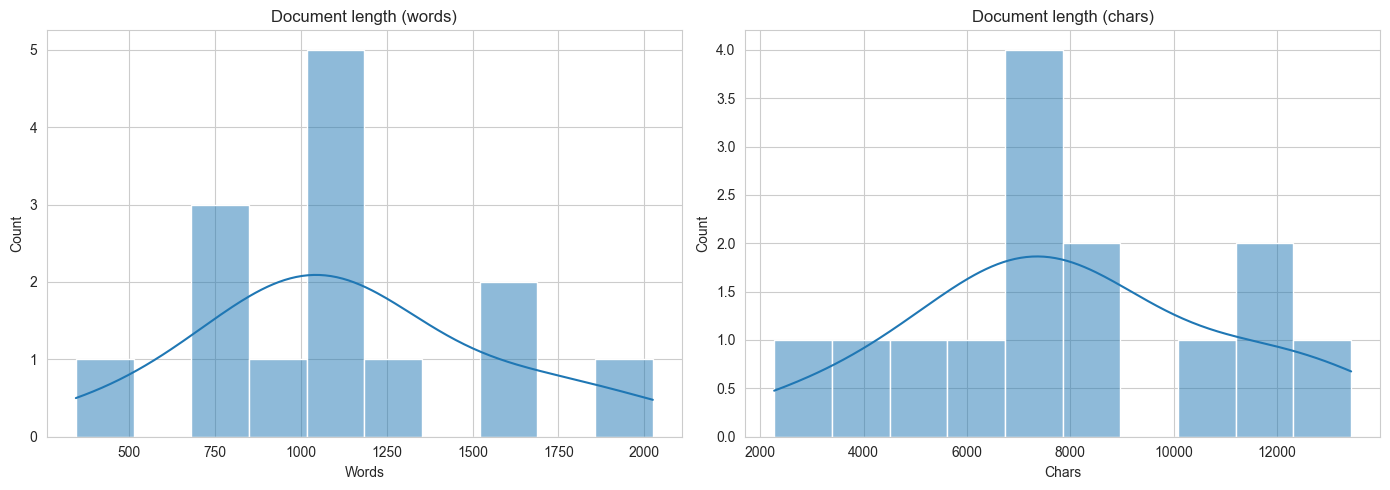

In [7]:
doc_stats = []
for doc in documents:
    sections = doc.get('sections', {})
    all_text = " ".join([t for t in sections.values() if t])
    doc_stats.append({
        "doc_id": doc.get("doc_id"),
        "length_chars": len(all_text),
        "length_words": len(all_text.split()),
        "year": doc.get("year")
    })

df_doc_stats = pd.DataFrame(doc_stats)
print(df_doc_stats.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_doc_stats["length_words"], bins=10, kde=True, ax=axes[0])
axes[0].set_title("Document length (words)")
axes[0].set_xlabel("Words")

sns.histplot(df_doc_stats["length_chars"], bins=10, kde=True, ax=axes[1])
axes[1].set_title("Document length (chars)")
axes[1].set_xlabel("Chars")

plt.tight_layout()
plt.show()

Загружено 81 чанков
       length_chars  length_words
count     81.000000     81.000000
mean    1585.209877    224.716049
std      578.958153     82.452446
min      160.000000     25.000000
25%     1266.000000    162.000000
50%     1874.000000    262.000000
75%     2035.000000    285.000000
max     2312.000000    338.000000


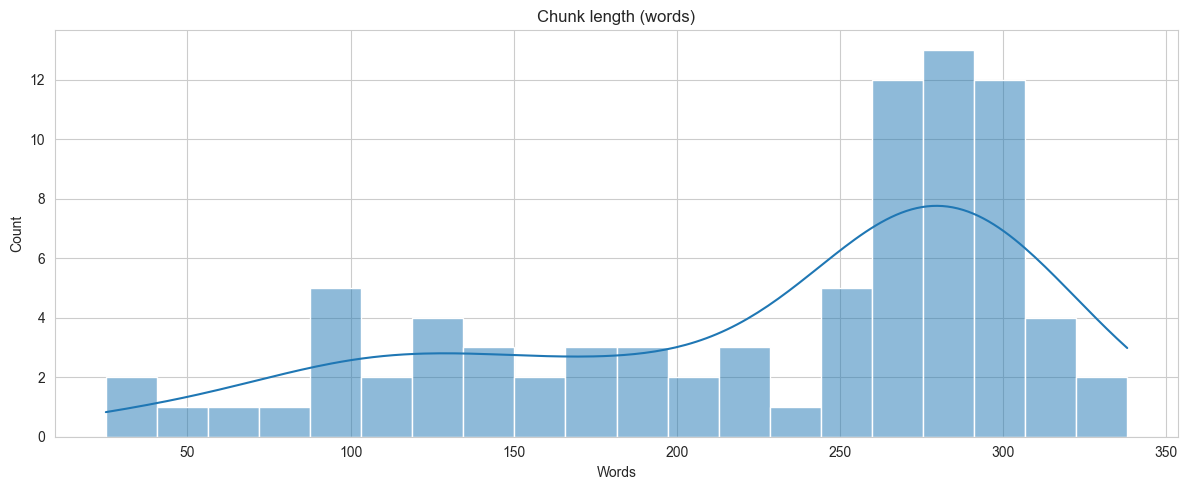

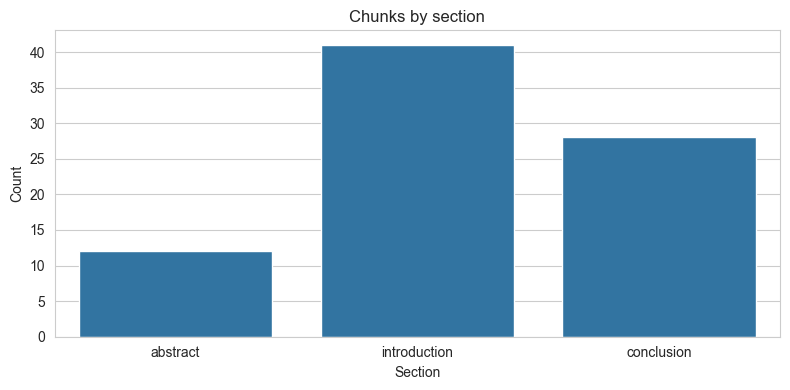

In [8]:
chunks_path = Path("../data/chunks.jsonl")
chunks = []
with open(chunks_path, 'r', encoding='utf-8') as f:
    for line in f:
        chunks.append(json.loads(line))

print(f"Загружено {len(chunks)} чанков")

chunk_stats = []
for chunk in chunks:
    text = chunk.get("text", "")
    chunk_stats.append({
        "chunk_id": chunk.get("chunk_id"),
        "doc_id": chunk.get("doc_id"),
        "section": chunk.get("section"),
        "length_chars": len(text),
        "length_words": len(text.split())
    })

df_chunks = pd.DataFrame(chunk_stats)
print(df_chunks.describe())

plt.figure(figsize=(12, 5))
sns.histplot(df_chunks["length_words"], bins=20, kde=True)
plt.title("Chunk length (words)")
plt.xlabel("Words")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(data=df_chunks, x="section")
plt.title("Chunks by section")
plt.xlabel("Section")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

d:\итмо\ml\biocad_trainee_task\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


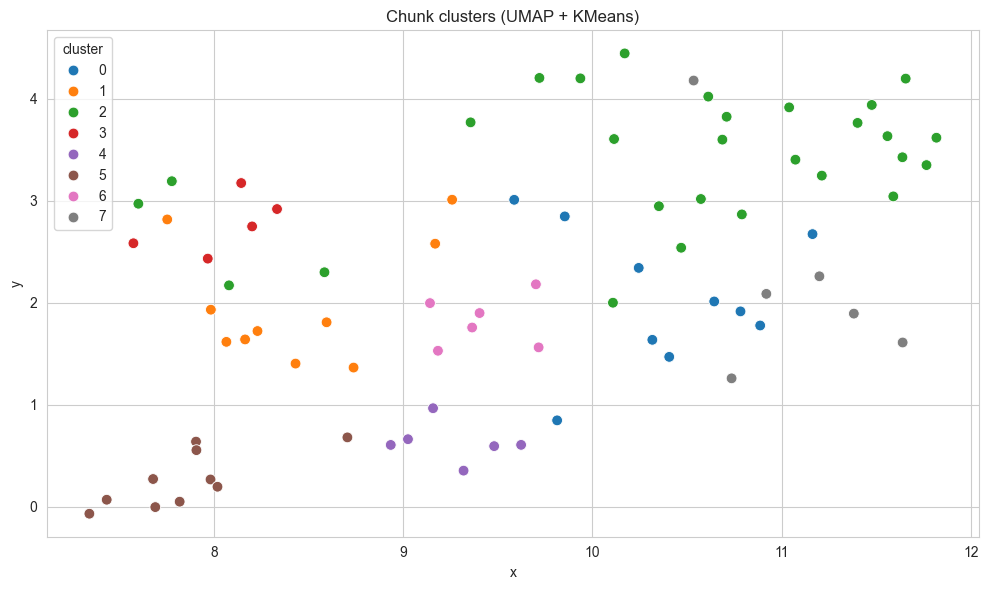

Cluster sizes:
cluster
0    10
1    10
2    28
3     5
4     6
5    10
6     6
7     6
Name: count, dtype: int64

Cluster 0 sample chunks:
- s Alzheimers disease is one of the dreadful diseases that has blown a full whistle for the cure of patients. Numerous pathophysio- logical changes have been recognized involving multiple signaling sys...
- Alzheimers disease (AD) research has been hindered by the lack of models that faithfully recapitulate the full profile of disease progression in a human genetic...

Cluster 1 sample chunks:
- and IL-6 as 40 candidate predictive biomarkers for cdsRNA-related neurodegenerative diseases. 41 Together, we find parallel neuroinflammatory mechanisms between TDP-43 associated-AD 42 and ALS and nom...
- 46 Efficacious therapies for cancer patients based on principles of precision medicine have 47 impacted millions of patients suffering from this heterogenous disease57. Mounting evidence 48 indicates ...

Cluster 2 sample chunks:
- Alzheimers disease, a s

In [9]:
import umap
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans


texts = [c.get("text", "") for c in chunks]
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X = vectorizer.fit_transform(texts)

n_components = min(50, X.shape[1] - 1) if X.shape[1] > 2 else 2
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_reduced = svd.fit_transform(X)

umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = umap_model.fit_transform(X_reduced)

k = max(2, min(8, len(texts) // 10))
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_reduced)

umap_df = pd.DataFrame({
    "x": X_umap[:, 0],
    "y": X_umap[:, 1],
    "cluster": clusters,
    "doc_id": [c.get("doc_id") for c in chunks],
    "section": [c.get("section") for c in chunks]
})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=umap_df, x="x", y="y", hue="cluster", palette="tab10", s=60)
plt.title("Chunk clusters (UMAP + KMeans)")
plt.tight_layout()
plt.show()

print("Cluster sizes:")
print(umap_df["cluster"].value_counts().sort_index())

for cluster_id in sorted(umap_df["cluster"].unique()):
    idx = umap_df[umap_df["cluster"] == cluster_id].index[:2]
    print(f"\nCluster {cluster_id} sample chunks:")
    for i in idx:
        text = texts[i].replace("\n", " ")
        print(f"- {text[:200]}...")